# **Razón Estandarizada de Morbilidad**
$$
REM_{Atlántico} = \frac{O_{Casos}}{E_{Tasa}}
$$

donde:  
- $ OBS_{casos} $= Casos observados en el departamento  
- $ ESP_{Tasa} $ = Casos esperados según la tasa departamental de incidencia.

El $REM$ mide cuántos casos hubo en un municipio comparado con lo que se esperaría según su población:
|Valor REM | Descripción |
|-------|-------------|
|<1 | Menos casos de lo esperado |
| 1 | Casos igual al esperado | 
| >1| Más casos de lo esperado | 


In [1]:
# [Configuración] Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

In [2]:
total_año = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_Total_A%C3%B1o.csv")
total_mun = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_Total_Municipio.csv")
periodo_mun = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_periodo_municipio.csv")

mapa_atl = gpd.read_file("./MAPAS/MAPAS_MUN/MGN_ADM_MPIO_GRAFICO.shp")
mapa_atl = mapa_atl.rename(columns={'mpio_cnmbr': 'municipio'})
mapa_atl = mapa_atl[mapa_atl['dpto_cnmbr'] == 'ATLÁNTICO']

## REM en el periodo estudiado

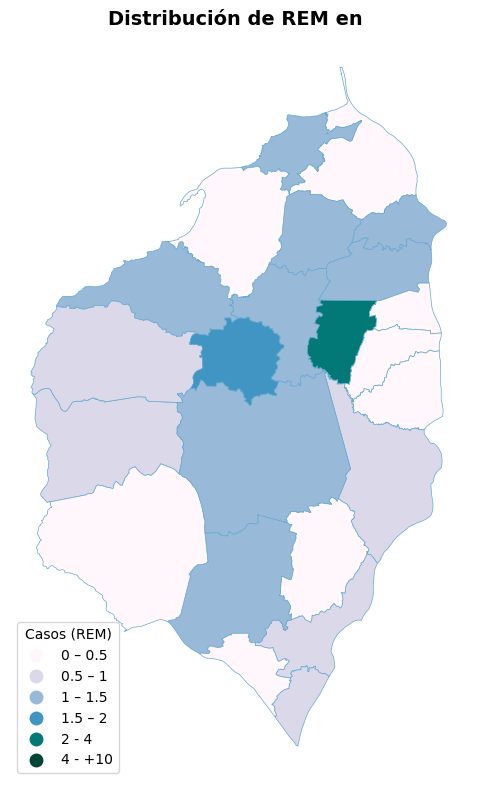

In [35]:
# Bins y etiquetas
bins = [0, 0.5, 1, 1.5, 2, 4, 12]
labels = ["0 – 0.5", "0.5 – 1", "1 – 1.5", "1.5 – 2", "2 - 4", "4 - +10"]

# Preparar datos
total_mun = total_mun.rename(columns={"MUNICIPIO": "municipio"})
gdf_plot = mapa_atl.merge(total_mun, on="municipio", how="left").fillna(0)

# Categorizar REM según bins
gdf_plot["casos_cat"] = pd.cut(
    gdf_plot["REM"], bins=bins, labels=labels, include_lowest=True
)

# Graficar mapa único
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf_plot.plot(
    column="casos_cat",
    cmap="PuBuGn",
    linewidth=0.5,
    edgecolor="#66A9CF",
    ax=ax,
    legend=True,
    legend_kwds={
        "title": "Casos (REM)",
        "loc": "lower left"
    }
)

ax.set_title("Distribución de REM en ", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## REM por año

In [3]:
total_año.head()

,MUNICIPIO,año,casos,poblacion,esperado,REM
0,BARANOA,2018,162,62371,74.797300,2.165854
1,BARANOA,2019,395,64550,96.491986,4.093604
2,BARANOA,2020,170,66927,60.503872,2.809738
3,BARANOA,2021,109,68800,148.508846,0.733963
4,BARANOA,2022,96,70464,200.095021,0.479772


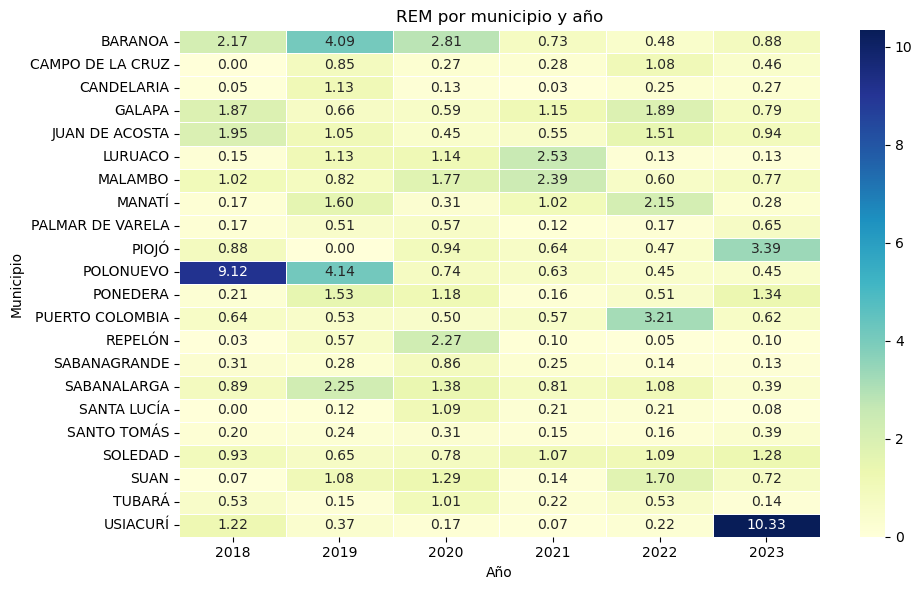

In [4]:
pivot_heat = total_año.pivot(index="MUNICIPIO", columns="año", values="REM")
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_heat,
    annot=True,         # Mostrar valores dentro del recuadro
    fmt=".2f",          # Formato de decimales
    cmap="YlGnBu",    # Colormap (puedes usar Blues, Viridis, etc.)
    linewidths=0.5,
    linecolor="white"
)

plt.title("REM por municipio y año")
plt.xlabel("Año")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()


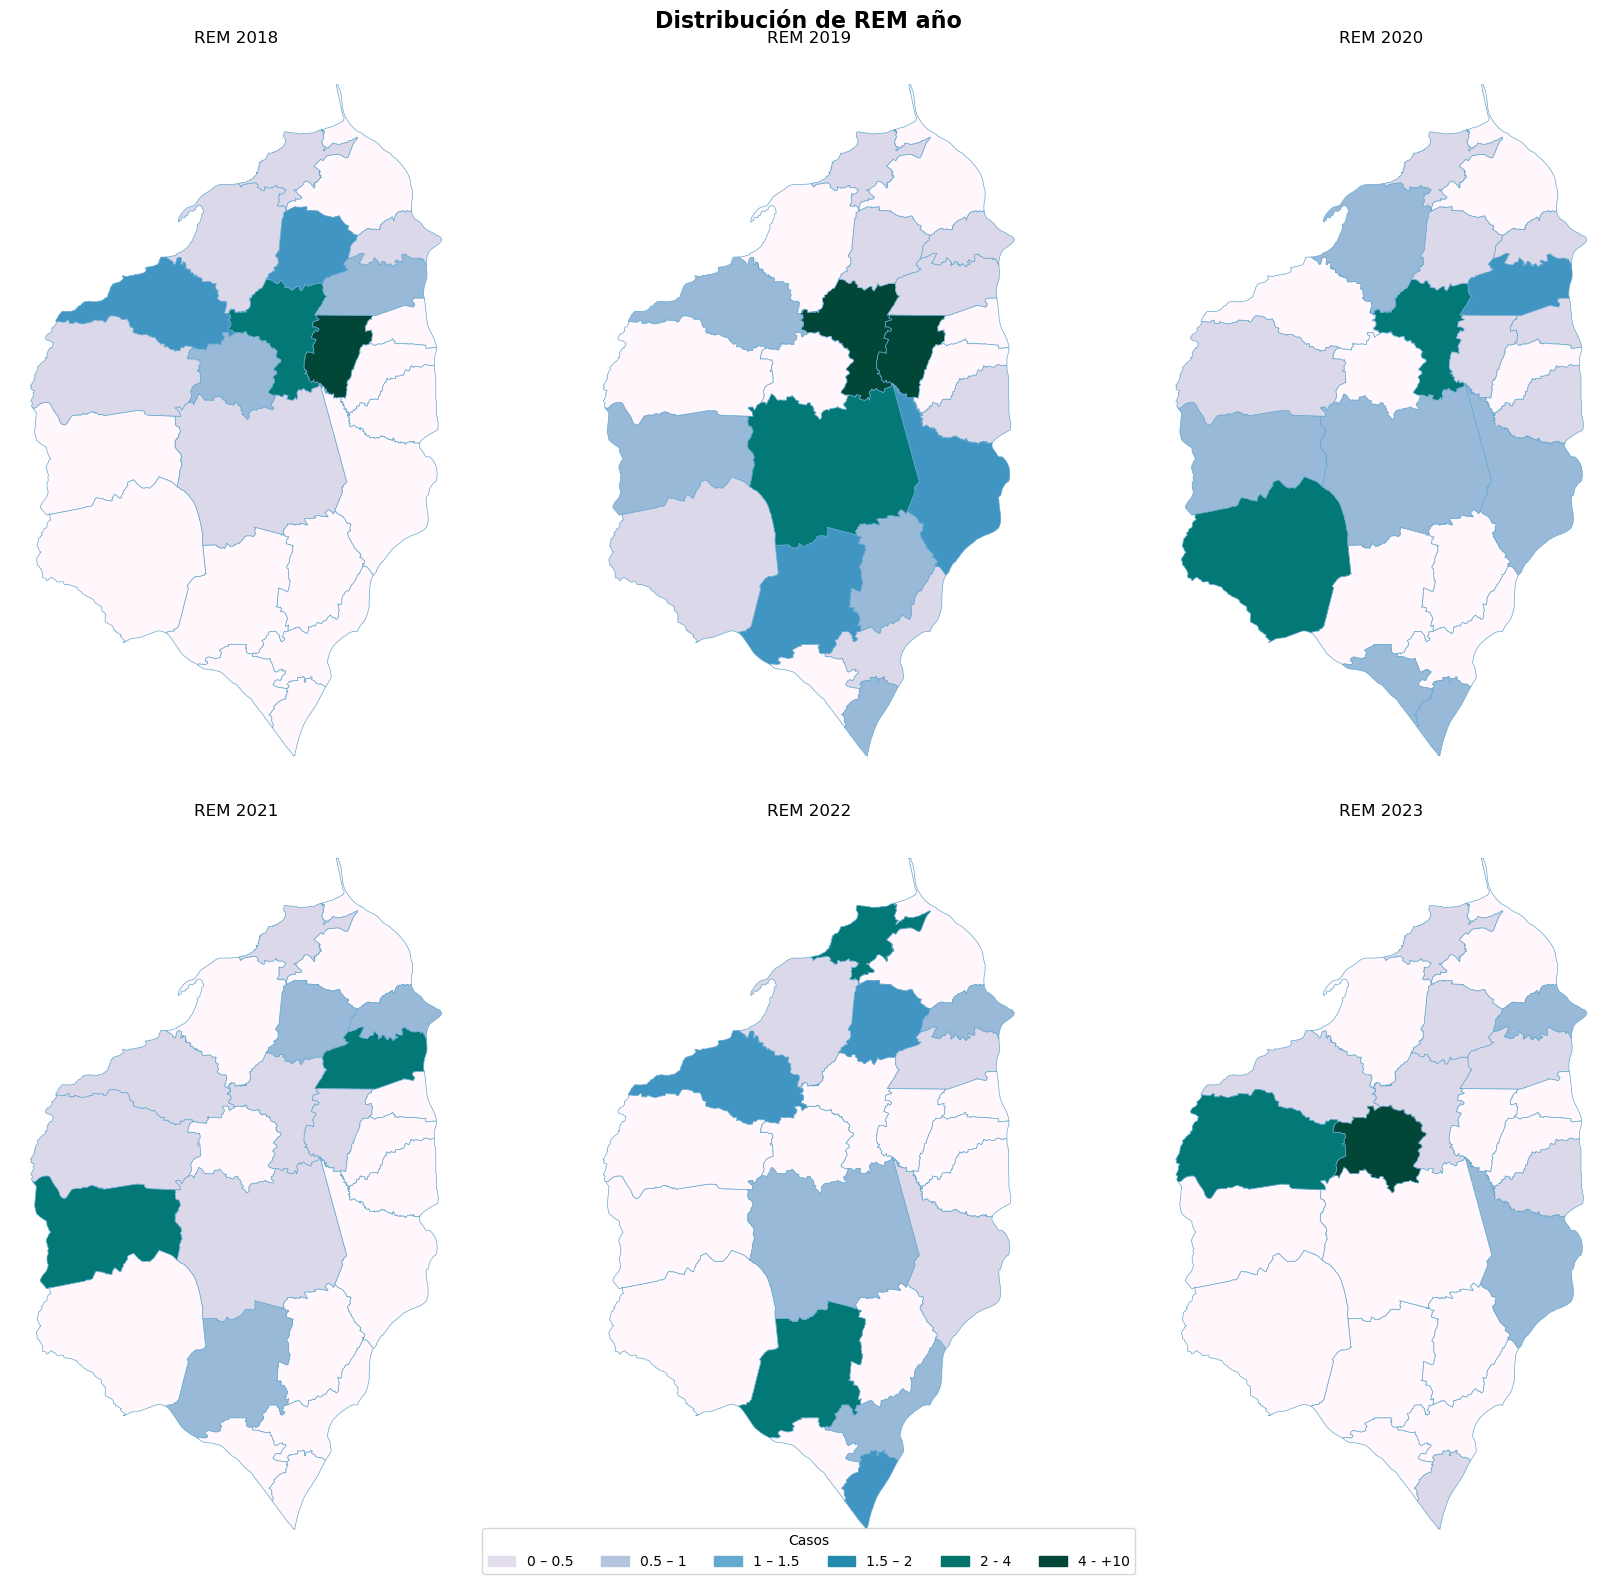

In [36]:
anios = sorted(total_año["año"].unique())[:6]  # 6 años
columnas = 3
filas = 2

fig, axes = plt.subplots(filas, columnas, figsize=(18, 16))
axes = axes.flatten()

bins = [0, 0.5, 1, 1.5, 2, 4, 12]
labels = ["0 – 0.5", "0.5 – 1", "1 – 1.5", "1.5 – 2", "2 - 4", "4 - +10"]

for i, anio in enumerate(anios):
    casos_anio = (
        total_año[total_año["año"] == anio]
        .groupby("MUNICIPIO", as_index=False)["REM"]
        .sum()
    )
    casos_anio = casos_anio.rename(columns={'MUNICIPIO':'municipio'})
    gdf_plot = mapa_atl.merge(casos_anio, on="municipio", how="left").fillna(0)

    gdf_plot['casos_cat'] = pd.cut(
        gdf_plot['REM'], bins=bins, labels=labels, include_lowest=True
    )

    gdf_plot.plot(
        column="casos_cat",
        cmap="PuBuGn",
        linewidth=0.5,
        edgecolor="#66A9CF",
        ax=axes[i],
        legend_kwds={
            "title": "Casos",
            "loc": "lower left"
        }
    )
    axes[i].set_title(f"REM {anio}")
    axes[i].axis("off")

cmap = plt.cm.PuBuGn
patches = [mpatches.Patch(color=cmap((i+1)/len(labels)), label=lab) for i, lab in enumerate(labels)] 
fig.legend(handles=patches, title="Casos", loc="lower center", ncol=len(labels))

fig.suptitle("Distribución de REM año", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

La distribución espacio-temporal de la REM, vizualizada en el mapa de calor, revela una evolución en la indensidad y focalización del dengue en el departamento. En el primer trienio (2018-2020) se identifican focos de alta morbilidad, donde los casos superaron significativamente lo esperado. El municipio de Polonuevo (2018 - 2019) se destaca por un valor excepcionalmente alto (REM > 4),alcanzando un pico de  9.12 en el 2018, lo que lo consolidó como el epicentro de la enfermedad. Junto a este, Baranoa, Sabanalarga y Repelón presentaron razones superiores a 2,  conformando otros núcleos de alta transmisión. También se destacan, con más casos de los esperados, los municipios de Juan de Acosta y Galapa (2018), Manatí y Ponedera (2019), y Malambo (2020). Este patrón de alta carga relativa difiere del descrito para el número absoluto de casos netos, subrayando la utilidad de la REM para identificar desproporciones epidemiológicas.

Para el segundo trienio (2021-2023) se observa una reconfiguración en la aparición de nuevos epicentros. La mayoría del territorio muestra una notable reducción (REM < 1), lo que indica una morbilidad dentro o por debajo de lo esperado. Sin embargo, surgen focos nuevos y aislados. Luruaco y Malambo (2021), junto con Manatí y Puerto Colombia (2022), se convierten en los puntos de mayor morbilidad (REM > 2), mostrando un pico notorio en el contexto departamental. Resulta llamativa la lejanía geográfica entre estos pares de municipios, lo que sugiere dinámicas de transmisión localizadas e independientes. Para 2023, Usiacurí se convierte en el epicentro absoluto, registrando el valor de REM más alto de todo el periodo (10.33). Así, es posible determinar una transición entre trienios que ilustra un escenario epidemiológico cambiante: se pasa de una epidemia intensa y multifocal a una situación de control basal con brotes esporádicos pero extremadamente severos.

## REM por municipio

In [5]:
total_mun = total_mun.rename(columns={"MUNICIPIO": "municipio"})
mapa_mun = mapa_atl.merge(total_mun, on='municipio', how='left')


C:\Users\danie\AppData\Local\Temp\ipykernel_11604\1480483060.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu', len(labels))


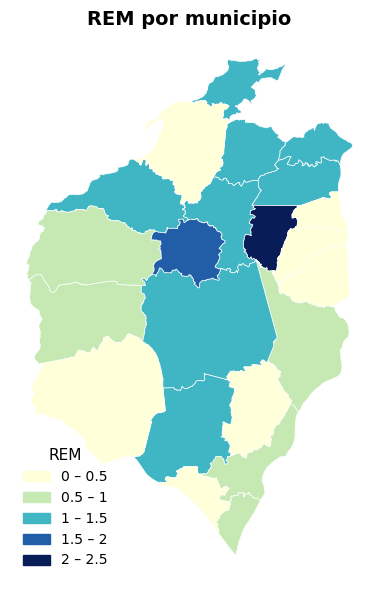

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm

bins = [0, 0.5, 1, 1.5, 2, 2.5] 
labels = [ "0 – 0.5", "0.5 – 1", "1 – 1.5","1.5 – 2", "2 – 2.5" ]

fig, ax = plt.subplots(figsize=(10, 6))

mapa_mun.plot(
    column='casos_cat',
    cmap='YlGnBu',
    linewidth=0.5,
    edgecolor='1',
    ax=ax
)

cmap = cm.get_cmap('YlGnBu', len(labels))
patches = [
    mpatches.Patch(color=cmap(i), label=label)
    for i, label in enumerate(labels)
]

ax.legend(
    handles=patches,
    title="REM",
    loc='lower left',
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_title("REM por municipio", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---------

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Cargar los datos
# -----------------------
df = pd.read_csv("C:\ETL_DENGUE\ARCHIVOS\REM\REM_Total_Año.csv")  
df_plot = df[df["año"].isin([2018, 2023])]
df_wide = df_plot.pivot(index="MUNICIPIO", columns="año", values="REM")
df_wide = df_wide.sort_values(2023)

municipios = df_wide.index
rem18 = df_wide[2018]
rem23 = df_wide[2023]

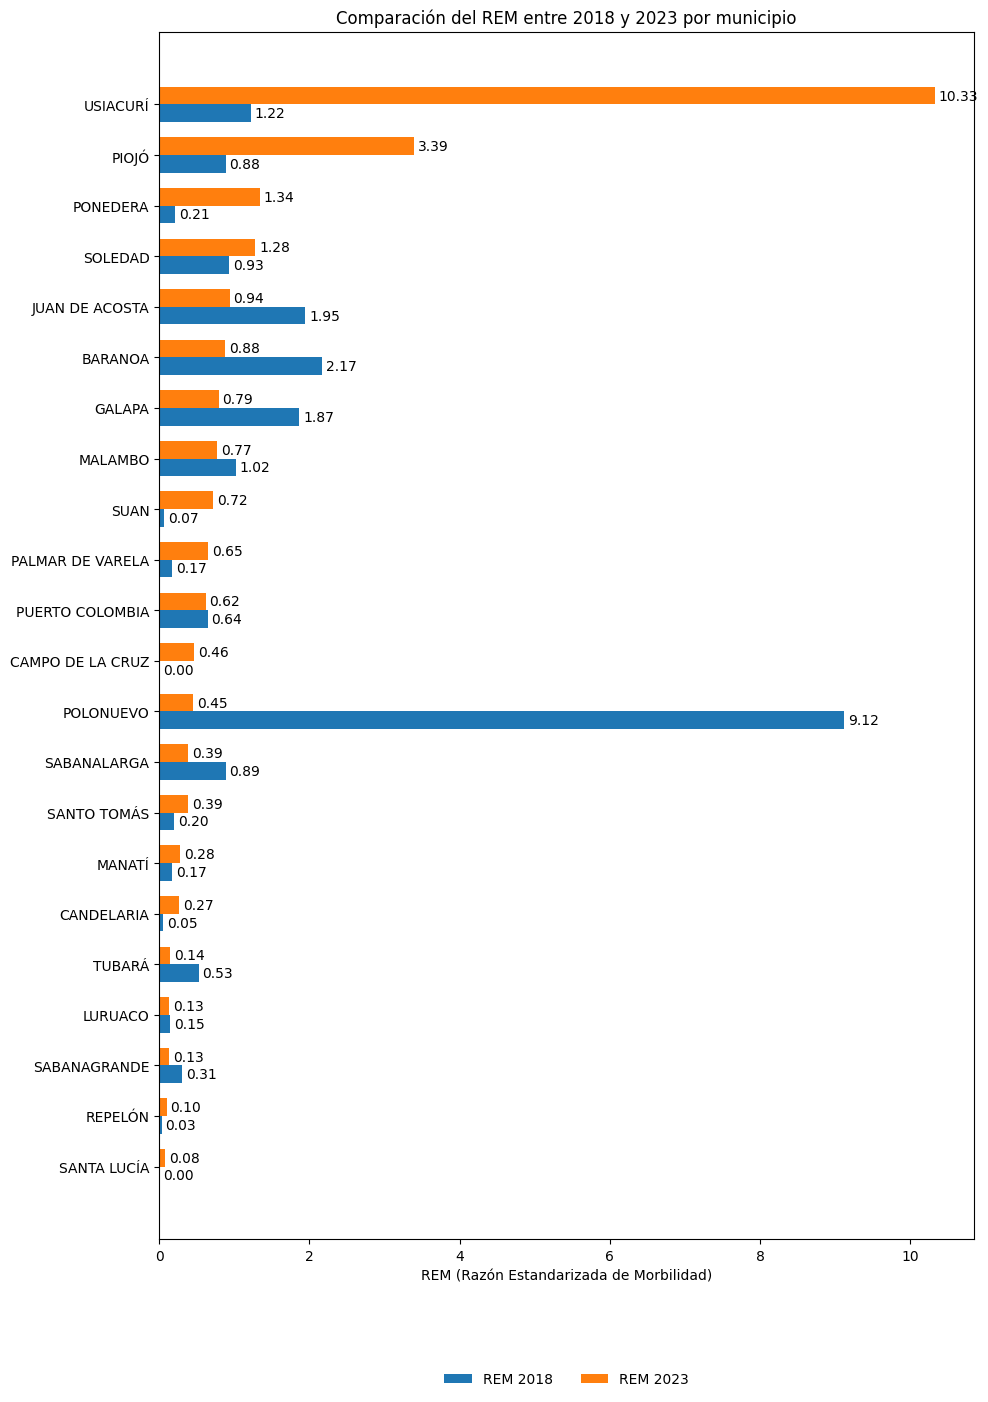

In [ ]:

plt.figure(figsize=(10, 14))

# Más separación entre barras
bar_height = 0.35
y_positions = range(len(municipios))

# Barras 2018 (abajo)
plt.barh(
    [y - bar_height/2 for y in y_positions],
    rem18,
    height=bar_height,
    label="REM 2018"
)

# Barras 2023 (arriba)
plt.barh(
    [y + bar_height/2 for y in y_positions],
    rem23,
    height=bar_height,
    label="REM 2023"
)

# Etiquetas numéricas
for i, v in enumerate(rem18):
    plt.text(v + 0.05, i - bar_height/2, f"{v:.2f}", va="center")

for i, v in enumerate(rem23):
    plt.text(v + 0.05, i + bar_height/2, f"{v:.2f}", va="center")

plt.yticks(list(y_positions), municipios)
plt.xlabel("REM (Razón Estandarizada de Morbilidad)")
plt.title("Comparación del REM entre 2018 y 2023 por municipio")

# Leyenda debajo del gráfico
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()